In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_1/FORS2.2021-10-05T04_55_53.494/UGC-409_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC409/UGC409_1/FORS2.2021-10-05T04_55_53.494/UGC-409_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     361   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        42   (2094, 964)   float32   


In [4]:
image_cut = image[55:175, 0:1890]
image_error_cut = image_error[55:175, 0:1890]

Text(0.5, 0, 'wavelenght')

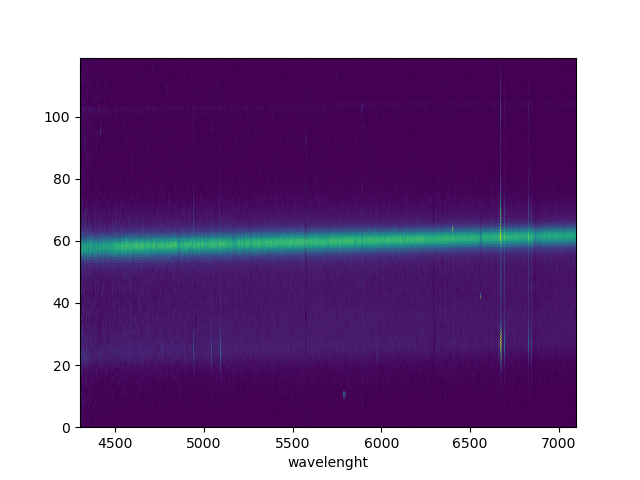

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.01736
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

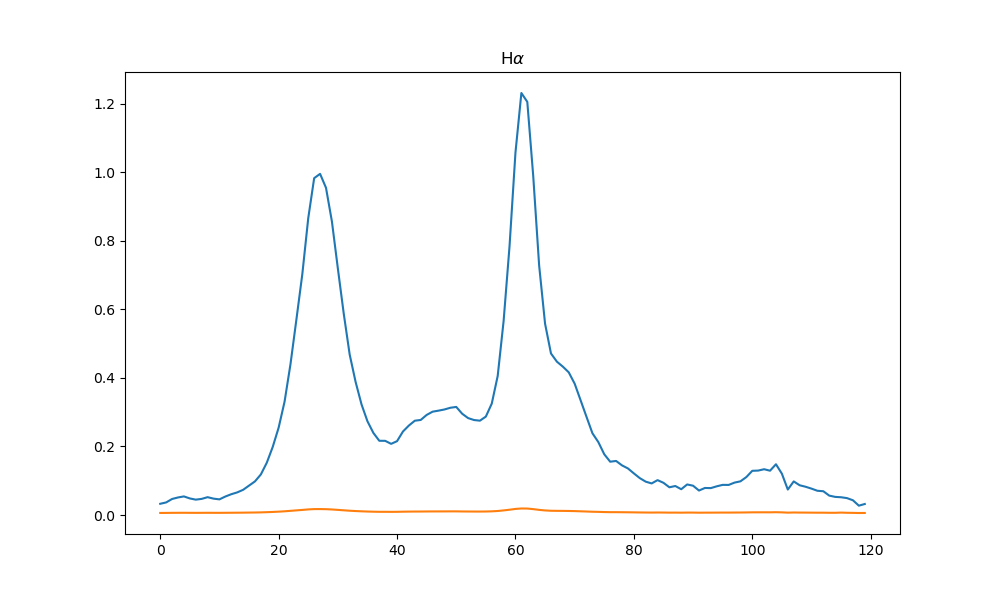

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 120, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

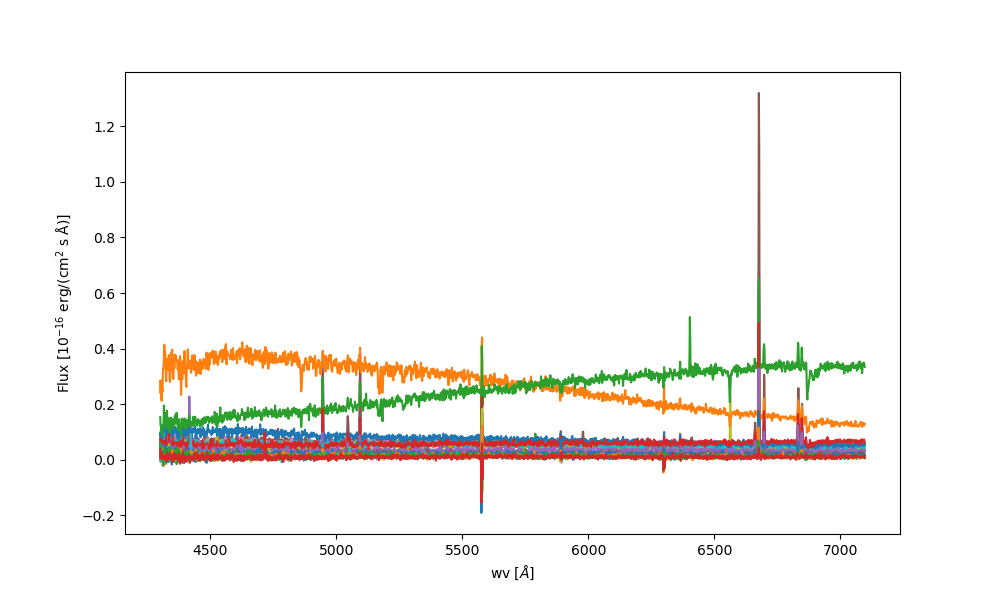

In [8]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('24ext', exist_ok=True)

spectra =  np.zeros((24, image_cut.shape[1]))
spectra_err = np.zeros((24, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(24):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('24ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [9]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 5950)*(wv < 6500)
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(24):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(24)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('24ext', 'SNR_24ext_continuum.csv')
df_path_snr = os.path.join('24ext', 'SNR_24ext_continuum.csv')
df_path_signal = os.path.join('24ext', 'Signal_24ext_continuum.csv')
df_path_noise = os.path.join('24ext', 'Noise_24ext_continuum.csv')
df_path_combined = os.path.join('24ext', 'Combined_24ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('24ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    1.626160    1.953097    2.626106    4.176155    7.967376   
Continuum_2    1.030404    1.224738    1.455628    2.206654    3.557282   
Continuum_3    2.317317    2.534975    3.578467    4.244224    5.745376   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  ...  \
Continuum_1    6.681974    6.238050    6.727031    6.172162     6.761504  ...   
Continuum_2    3.709538    4.149700    4.102263    3.531529     4.321252  ...   
Continuum_3    7.600934    8.392103    8.759183    8.150812     7.897228  ...   

             Spectrum_15  Spectrum_16  Spectrum_17  Spectrum_18  Spectrum_19  \
Continuum_1     3.959860     2.784735     2.309245     2.378599     1.996825   
Continuum_2     2.432266     1.291592     1.238589     1.390844     1.060661   
Continuum_3     5.453778     3.921564     3.167157     2.820611     2.732679   

             Spectrum_20  Spectrum_21 

## Redshift

In [10]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Spettro 1
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 5
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 6677.619999999299   emission              1606
4783.2199999998575 absorption               326
 5575.019999999624 absorption               861
 5579.459999999623 absorption               864
 6297.259999999411 absorption              1349



If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 2
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 3
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
6677.619999999299   emission              1606
5575.019999999624 absorption               861
6297.259999999411 absorption              1349
Spettro 3
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 7
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
5788.139999999561   emission              1005
6677.619999999299   emission              1606
4365.859999999981 absorption                44
5575.019999999624 absorption               861
5579.459999999623 absorption               864
 5893.21999999953 absorption              1076
6297.259999999411 absorption              1349
Spettro 4
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 14
   line_center     line_type  line_cente


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 12
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 24
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 4626.339999999904   emission               220
 5094.019999999766   emission               536
 5577.979999999623   emission               863
  6300.21999999941   emission              1351
 6676.139999999299   emission              1605
 6696.859999999293   emission              1619
 6831.539999999253   emission              1710
6847.8199999992485   emission              1721
 4302.219999999999 absorption                 1
 4306.659999999998 absorption                 4
 4309.619999999997 absorption                 6
 4383.619999999975 absorption                56
 4404.339999999969 absorption                70
 4860.179999999835 absorption               378
 4917.899999999818 absorption               417
 5170.979999999743 absorption               588
  5182.8199999997


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 23
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 15
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
           4300.74   emission                 0
 4337.739999999989   emission                25
 4650.019999999897   emission               236
 5092.539999999766   emission               535
6674.6599999992995   emission              1604
 6695.379999999293   emission              1618
 6830.059999999254   emission              1709
 6844.859999999249   emission              1719
 6893.699999999235   emission              1752
 4311.099999999997 absorption                 7
5576.4999999996235 absorption               862
 6297.259999999411 absorption              1349
  6301.69999999941 absorption              1352
 6326.859999999402 absorption              1369
 6539.979999999339 absorption              1513



If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 24
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 42
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
           4300.74   emission                 0
 4391.019999999973   emission                61
 4485.739999999945   emission               125
 4715.139999999878   emission               280
 5092.539999999766   emission               535
 5165.059999999745   emission               584
 5515.819999999641   emission               821
   6334.2599999994   emission              1374
6674.6599999992995   emission              1604
 6682.059999999297   emission              1609
 6695.379999999293   emission              1618
 6862.619999999244   emission              1731
               ...        ...               ...
 5575.019999999624 absorption               861
 5579.459999999623 absorption               864
 6038.259999999487 absorption              1174
 6187.73999999944

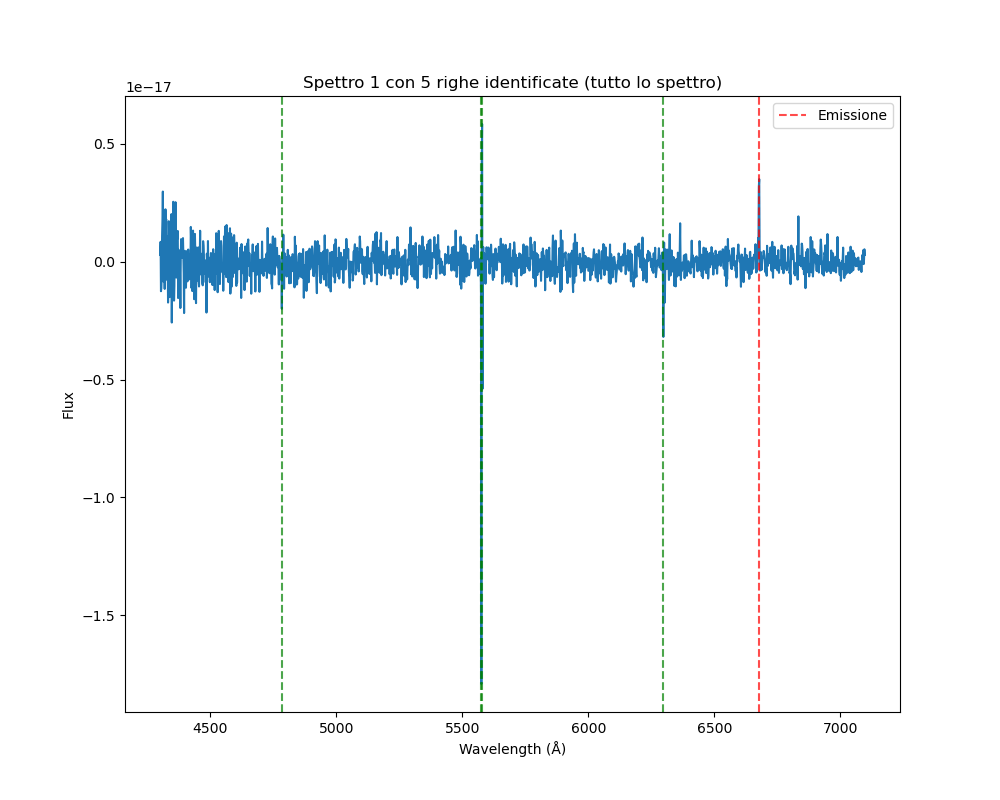

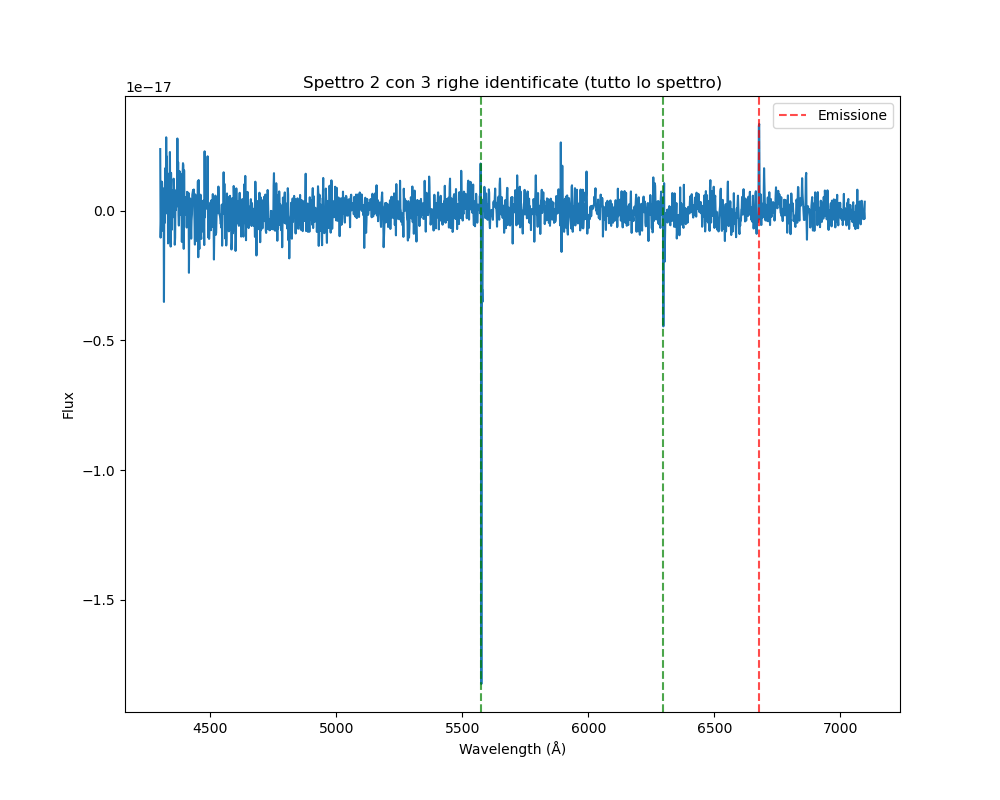

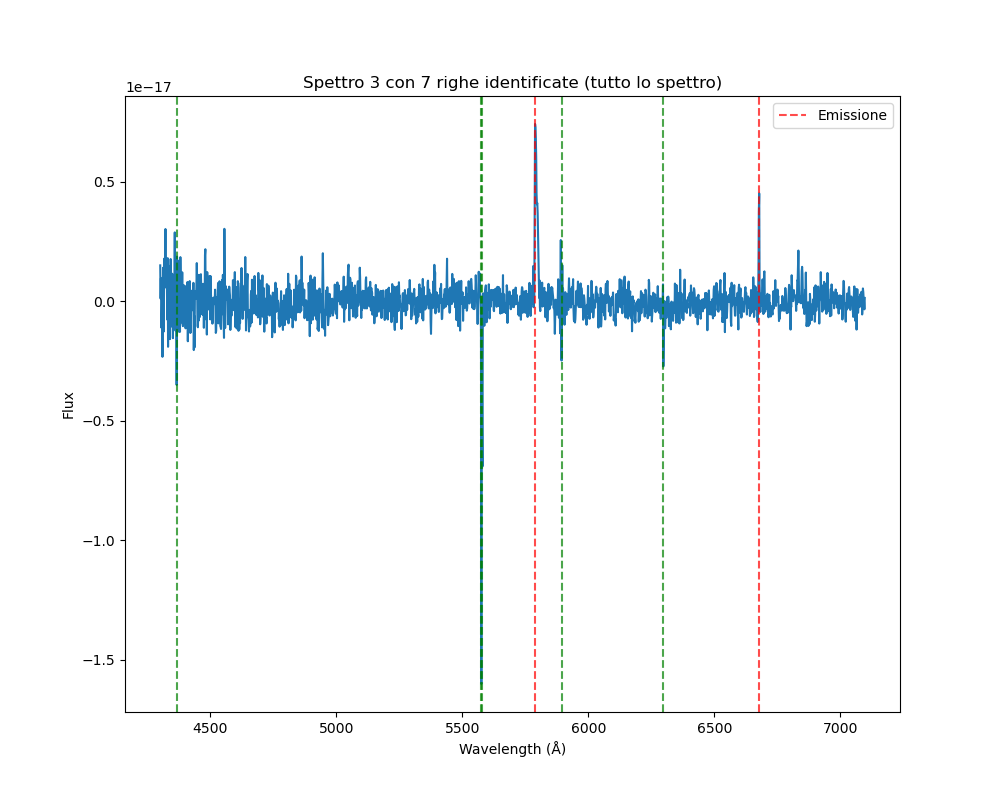

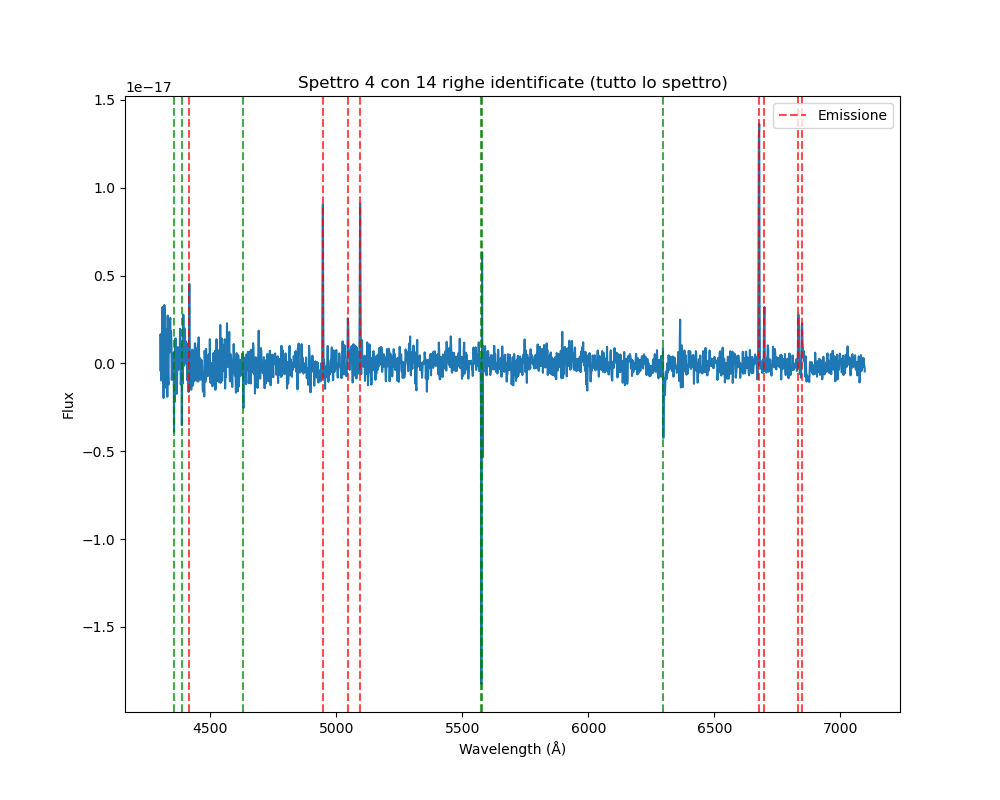

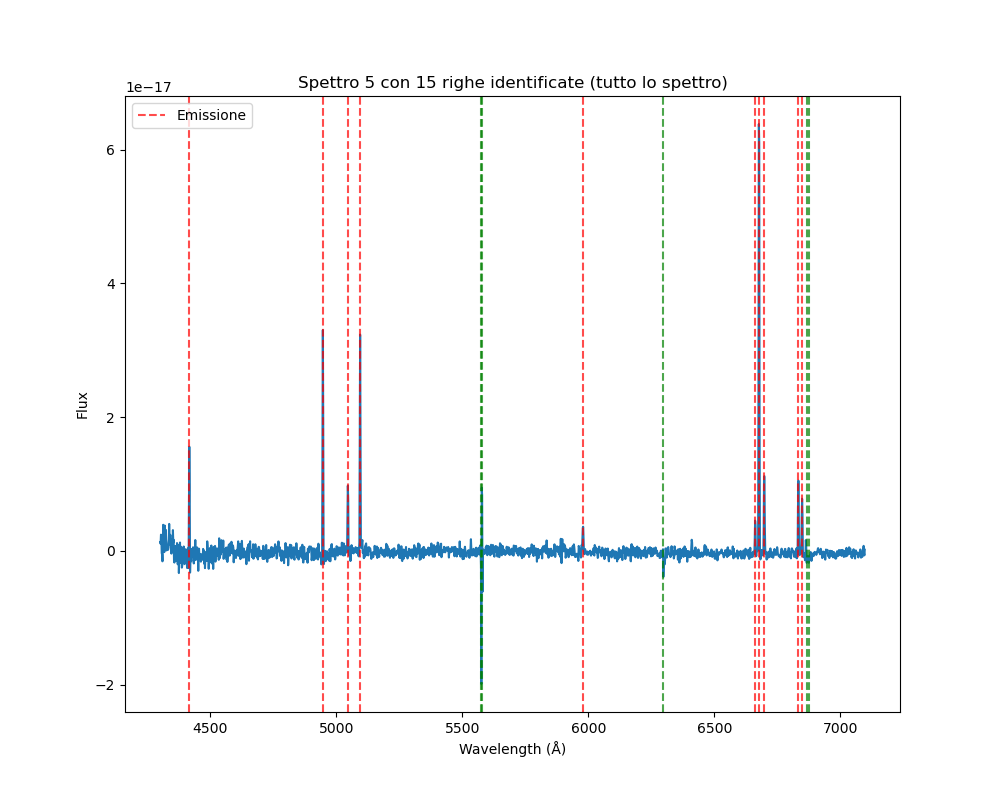

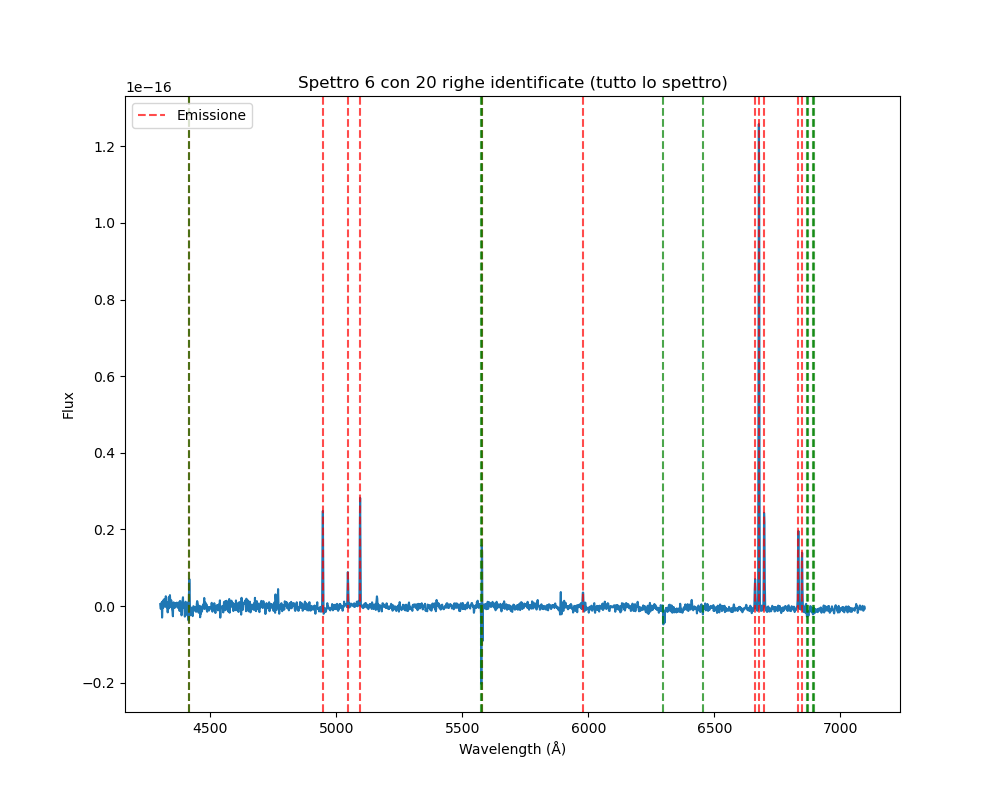

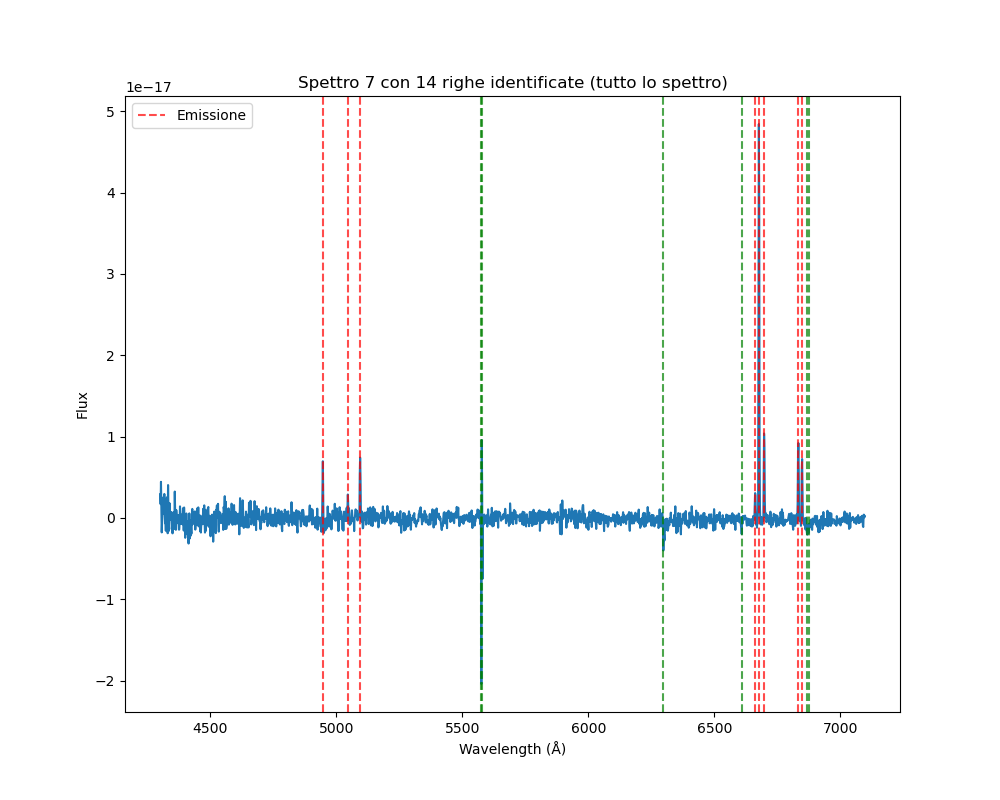

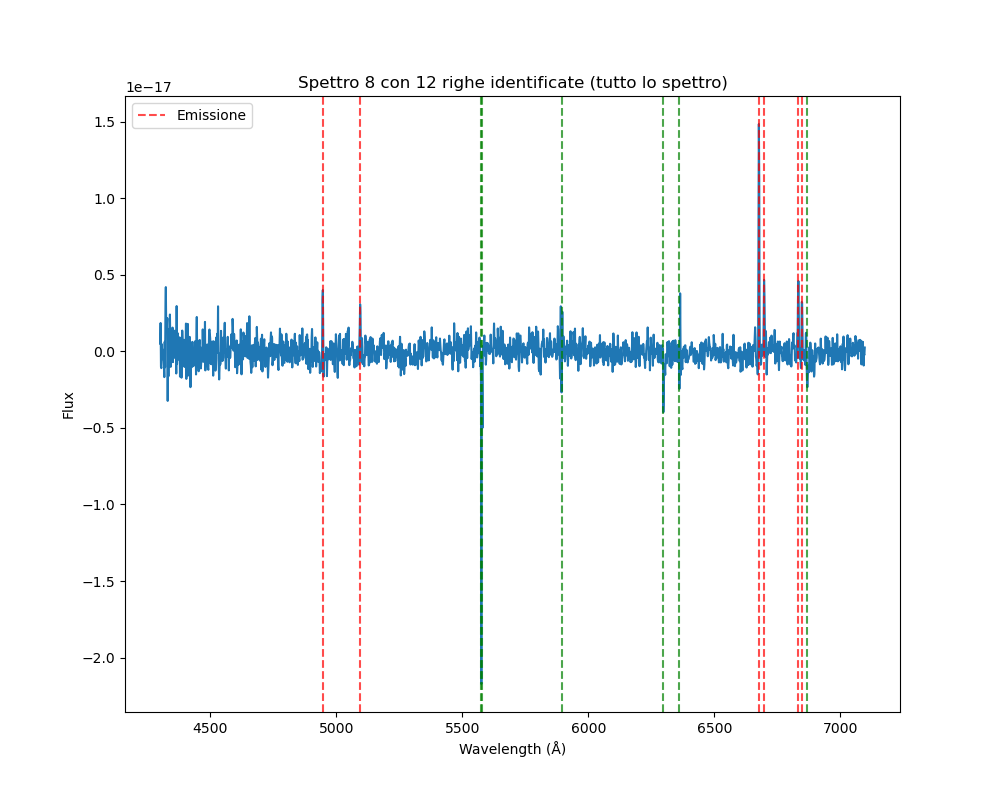

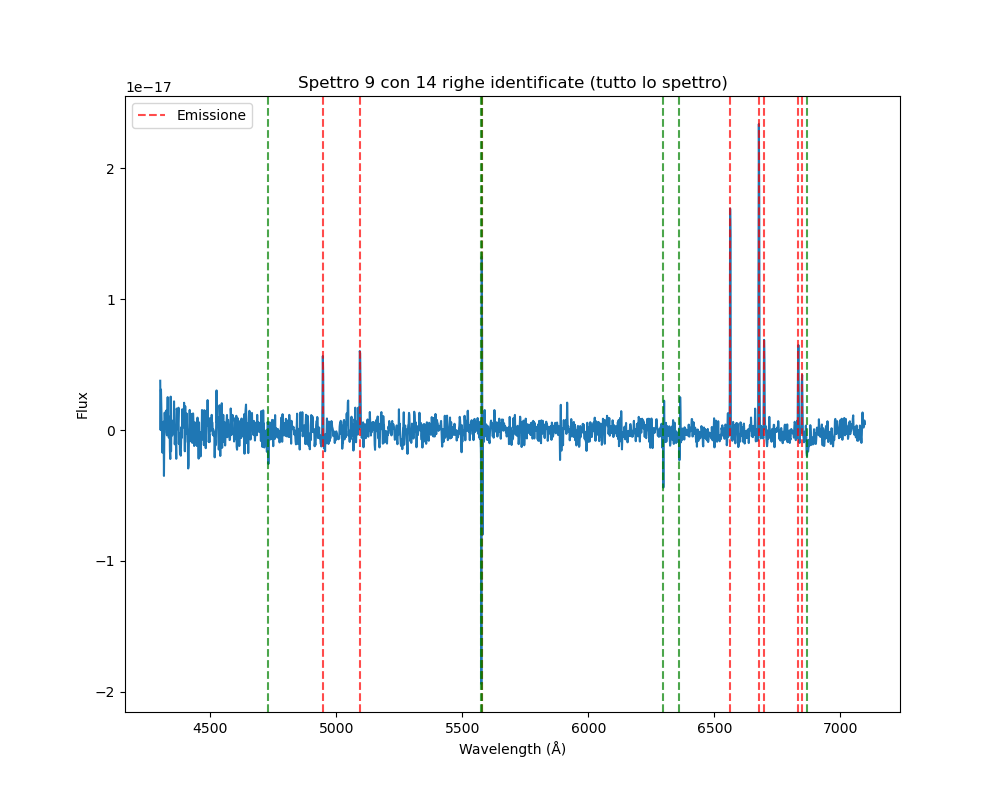

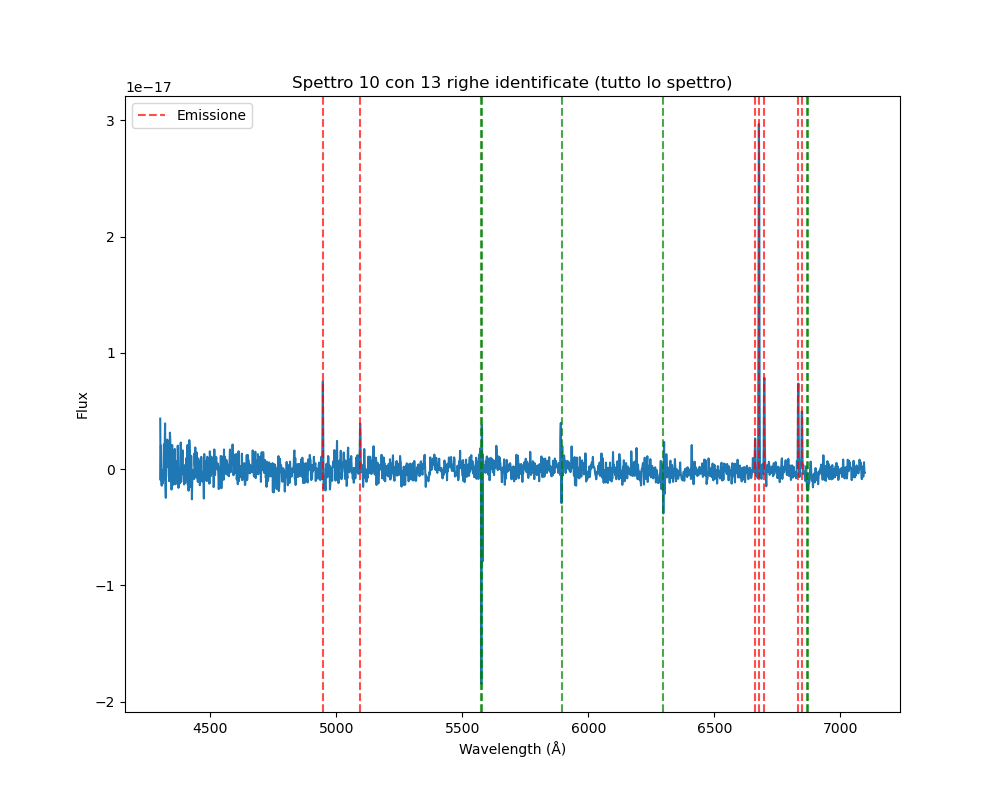

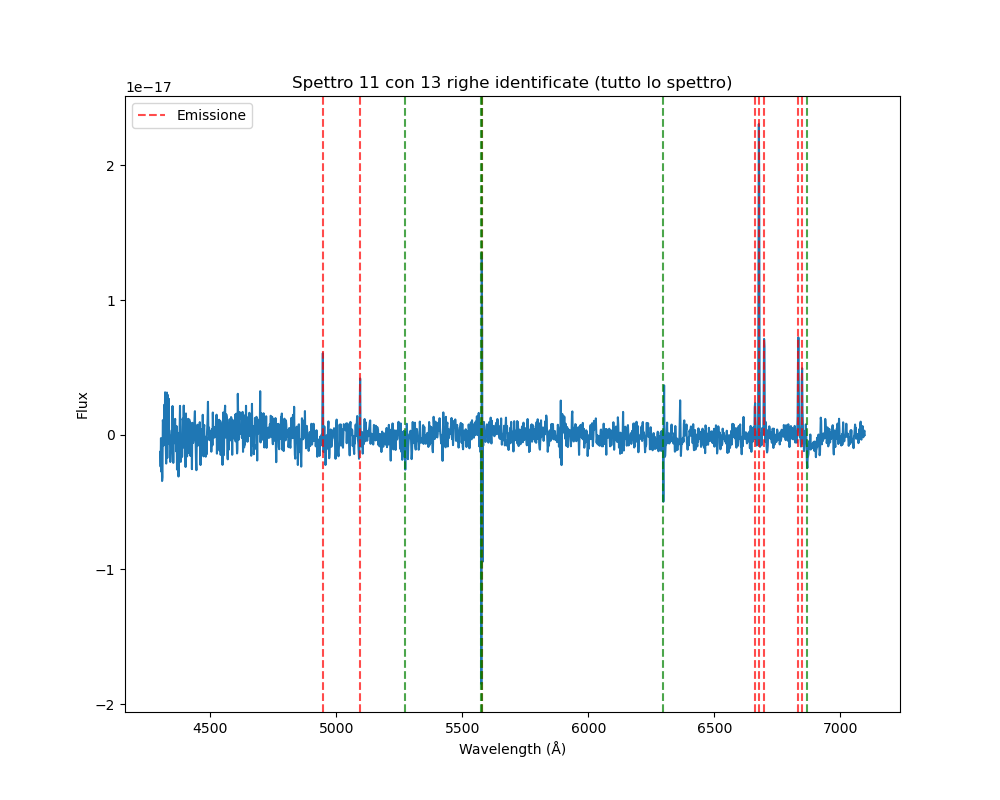

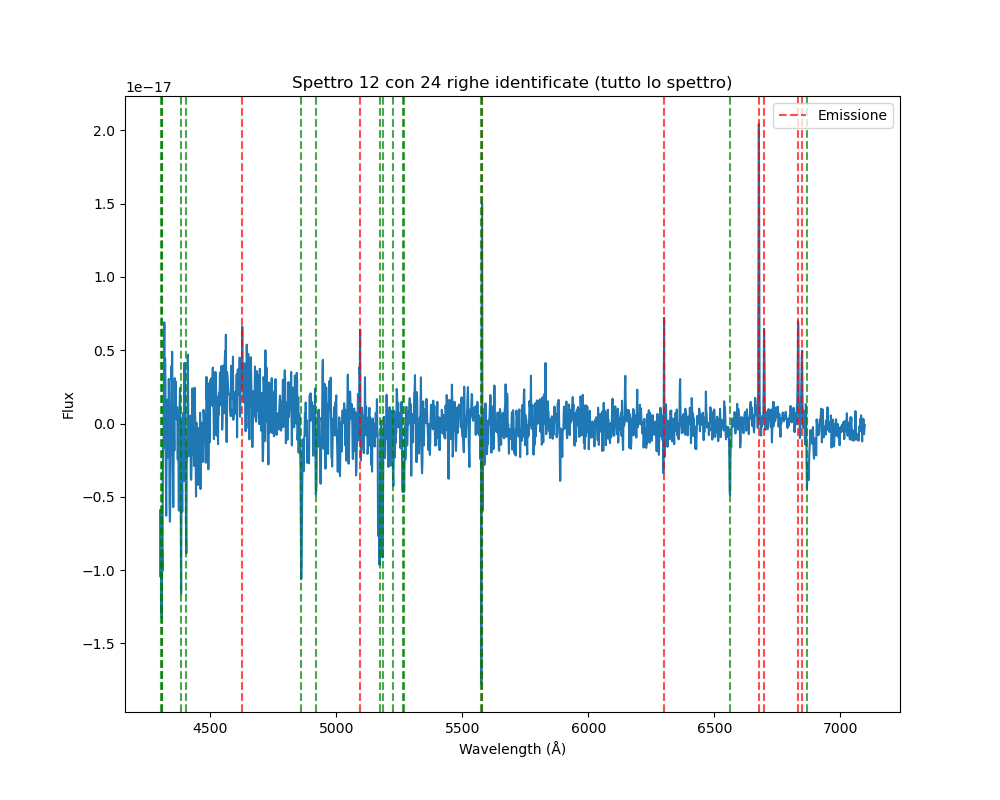

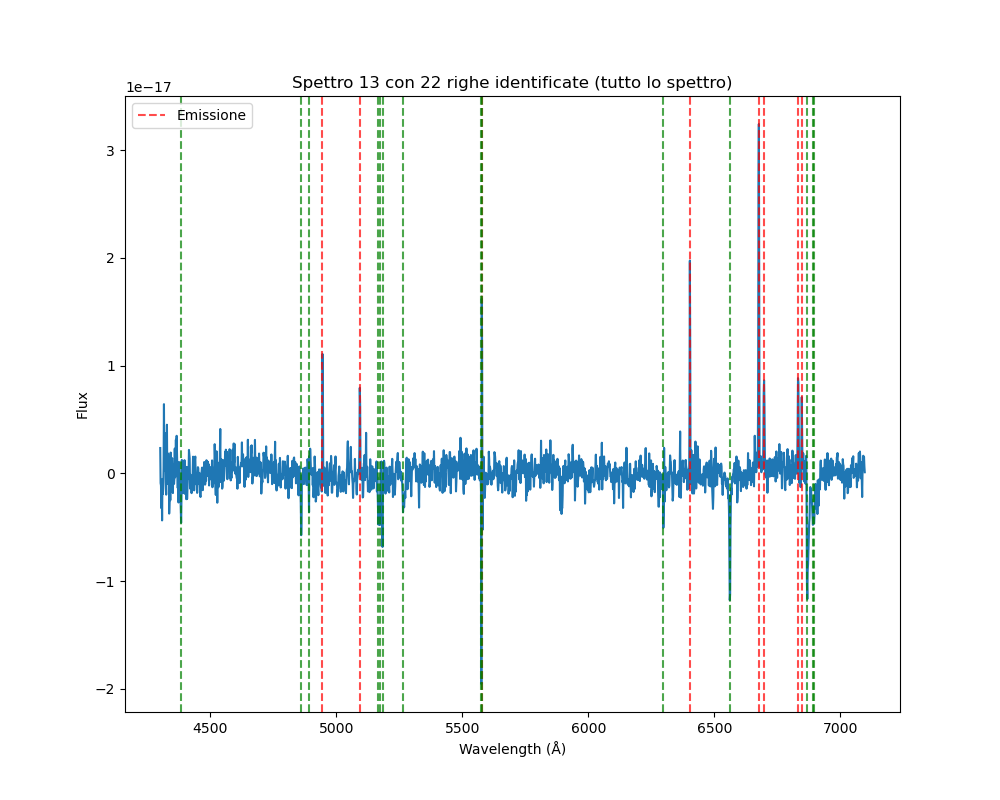

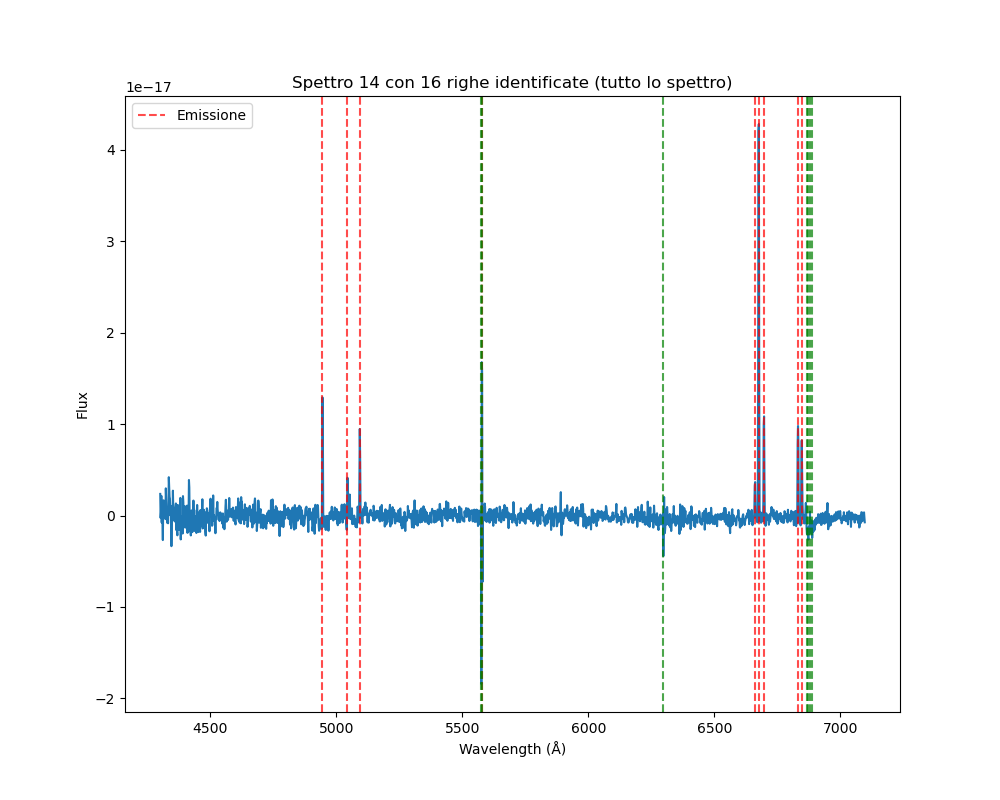

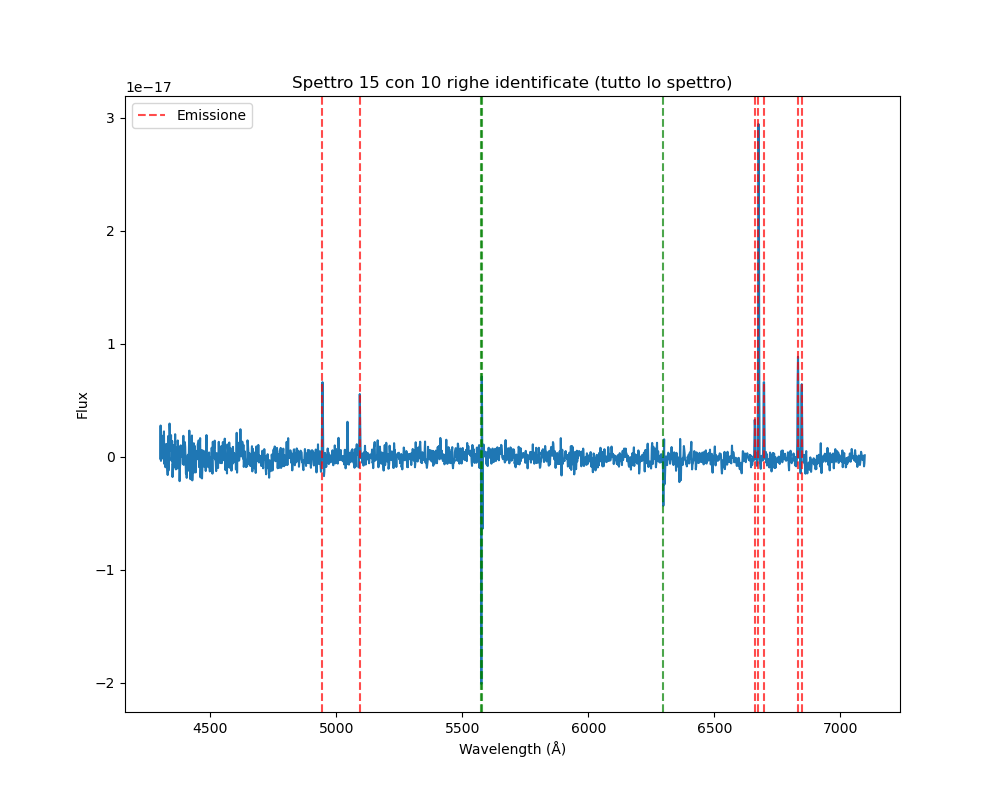

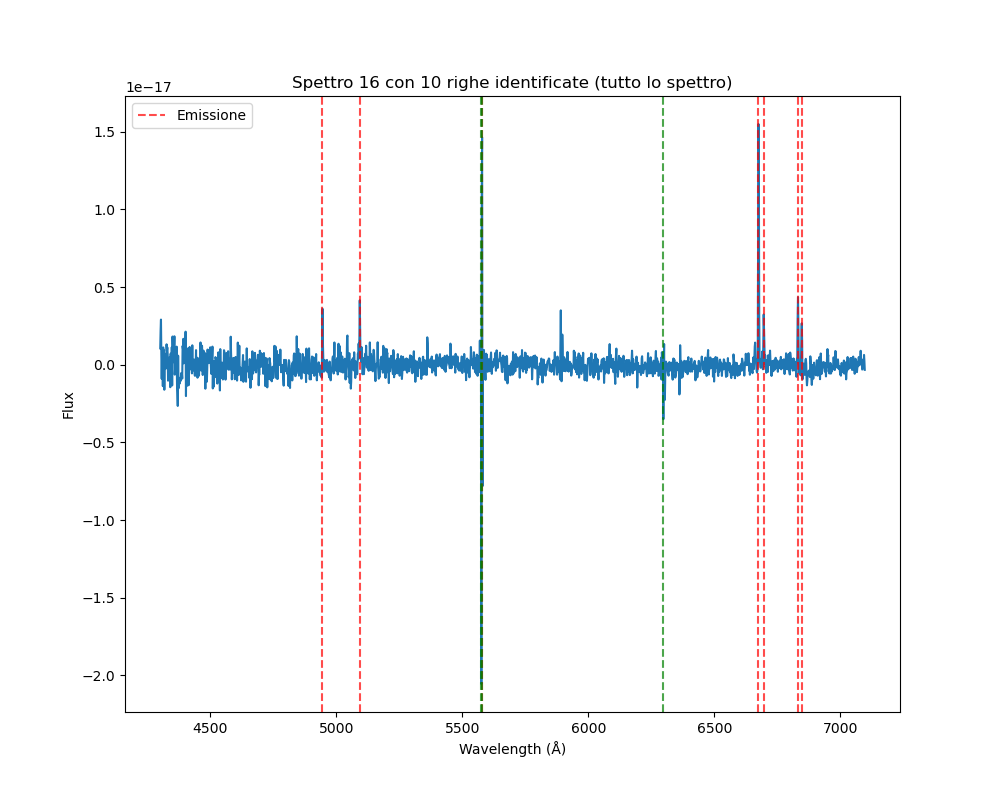

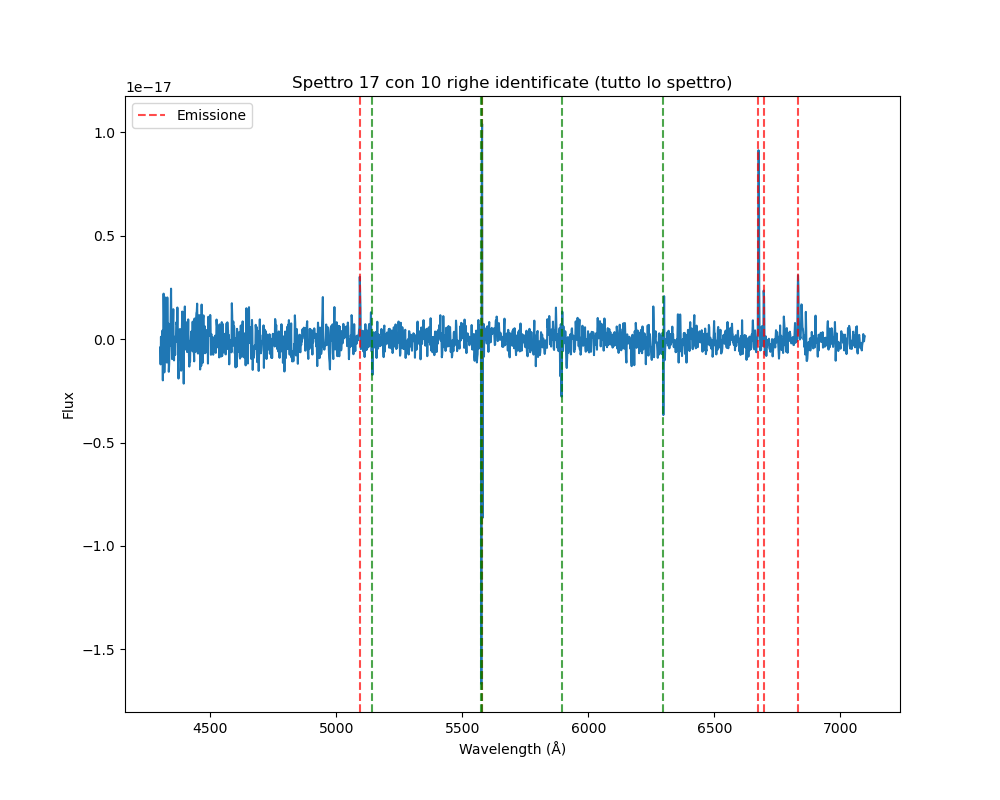

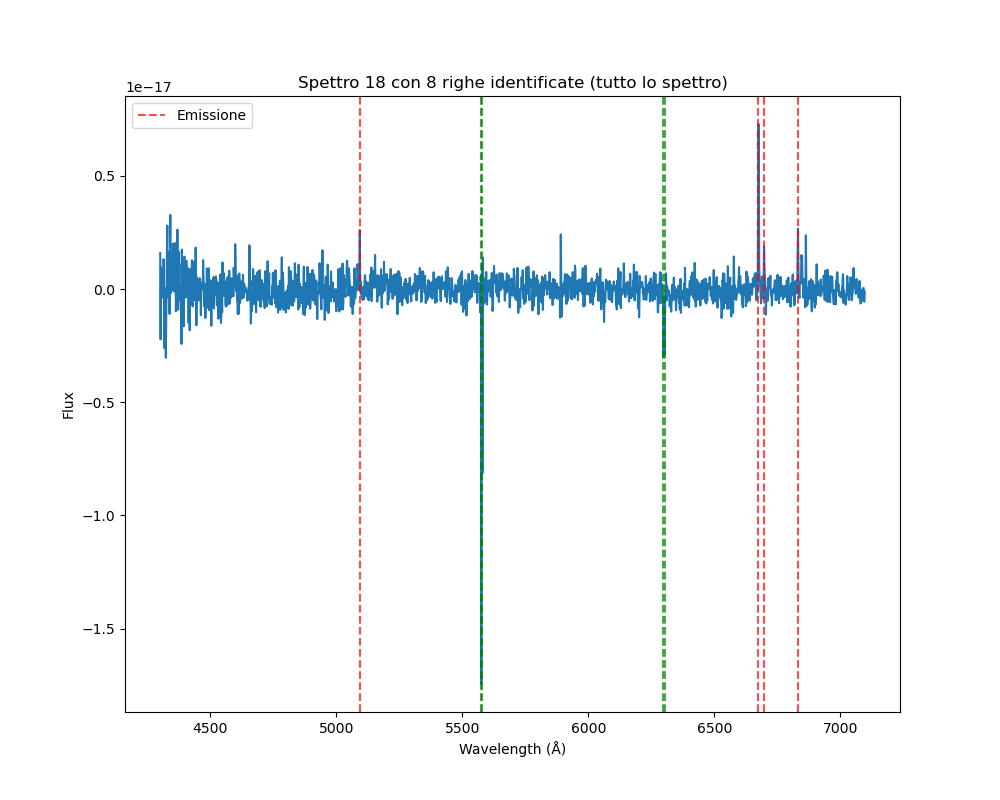

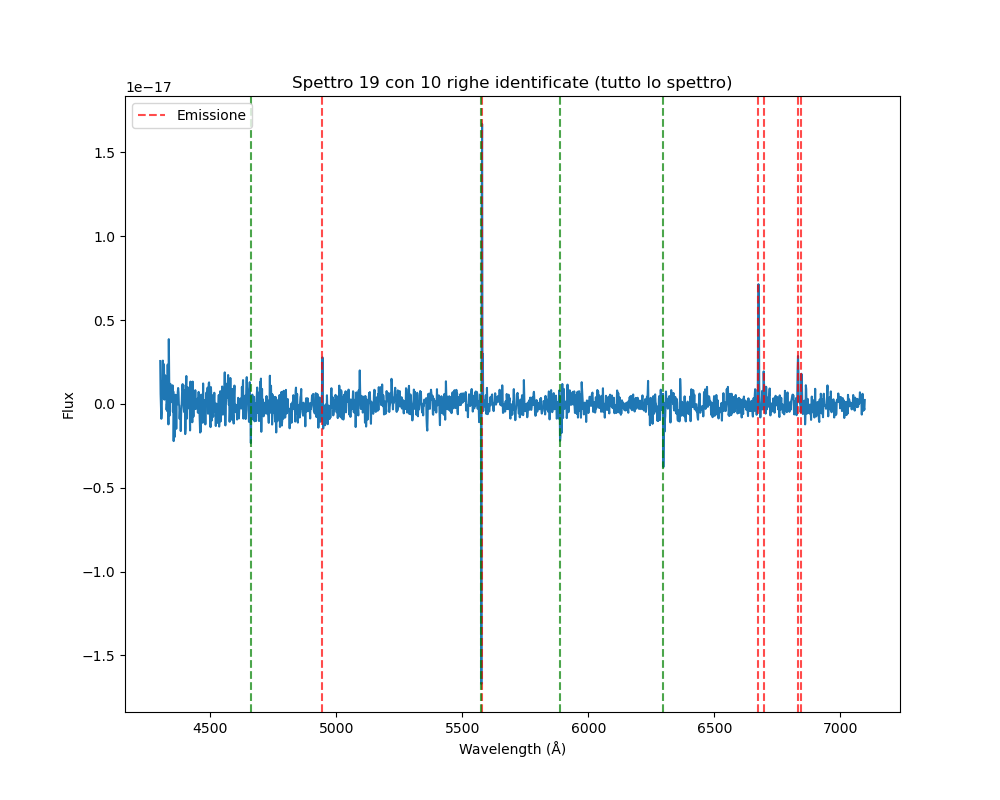

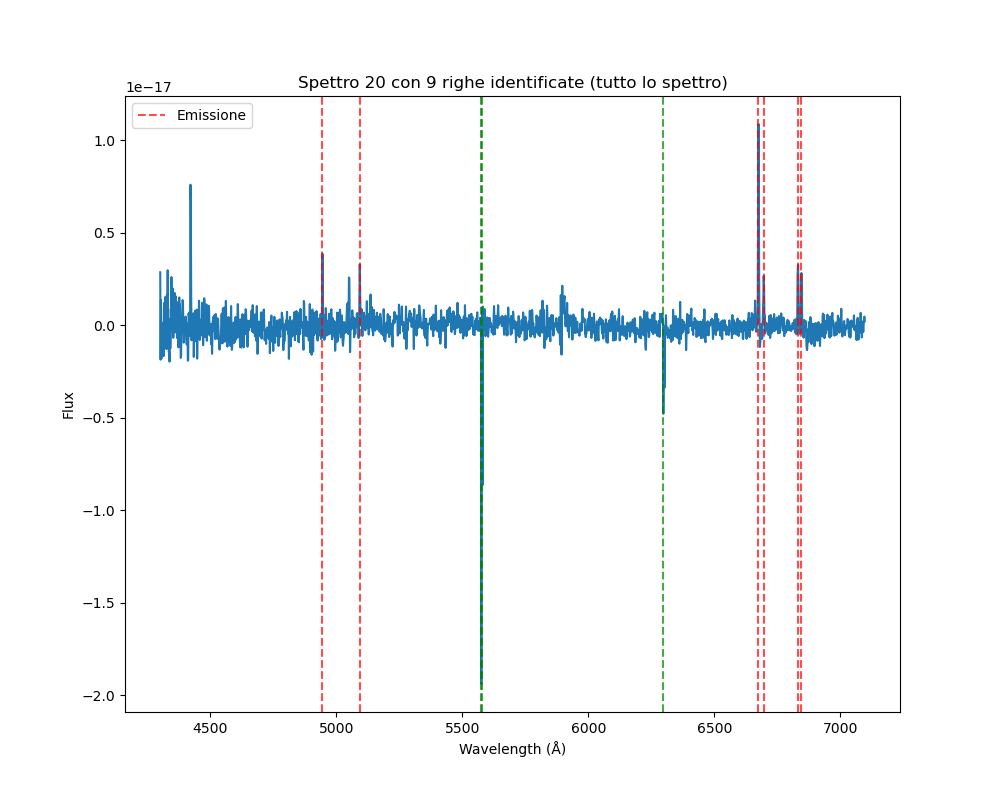

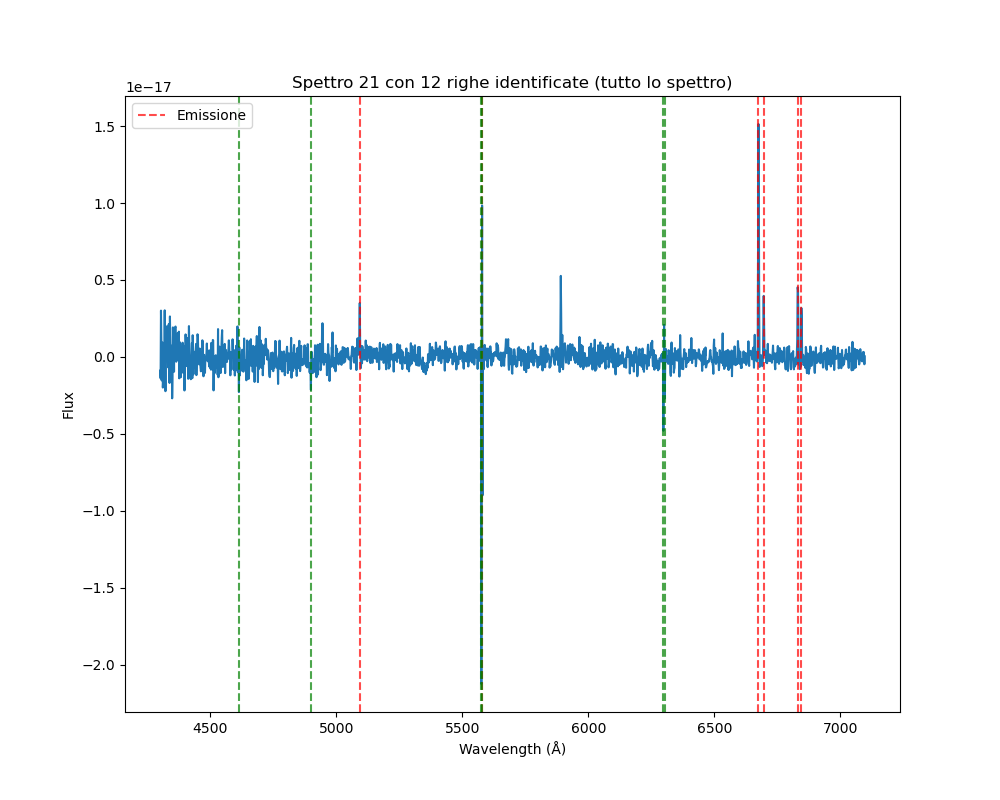

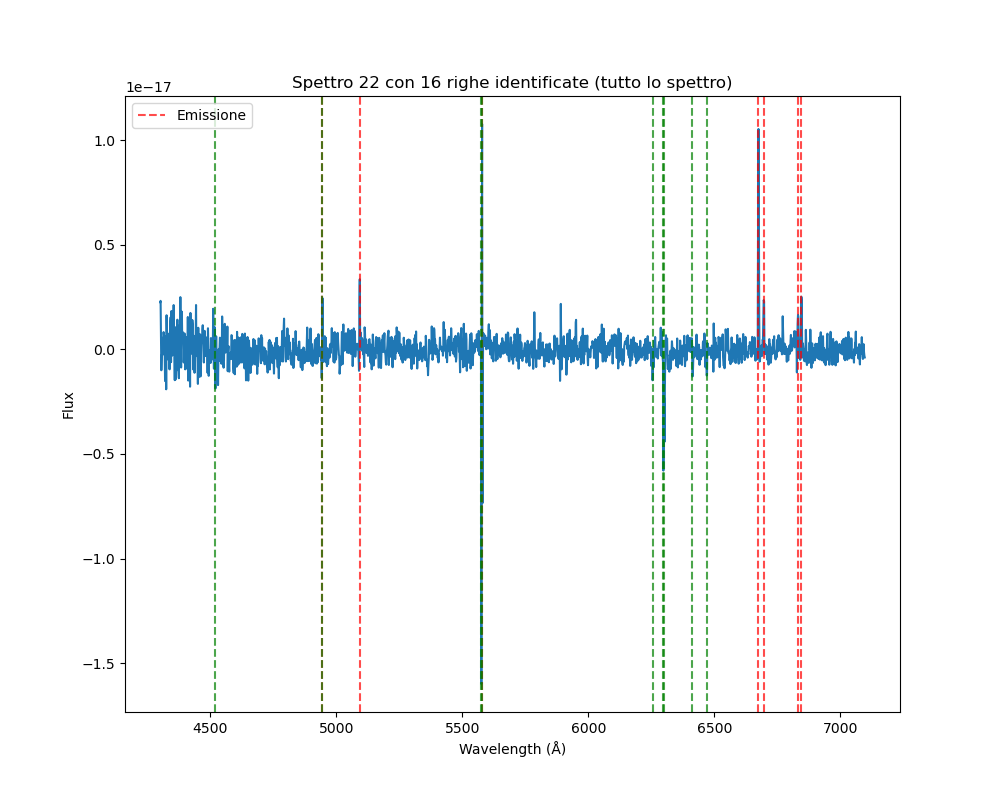

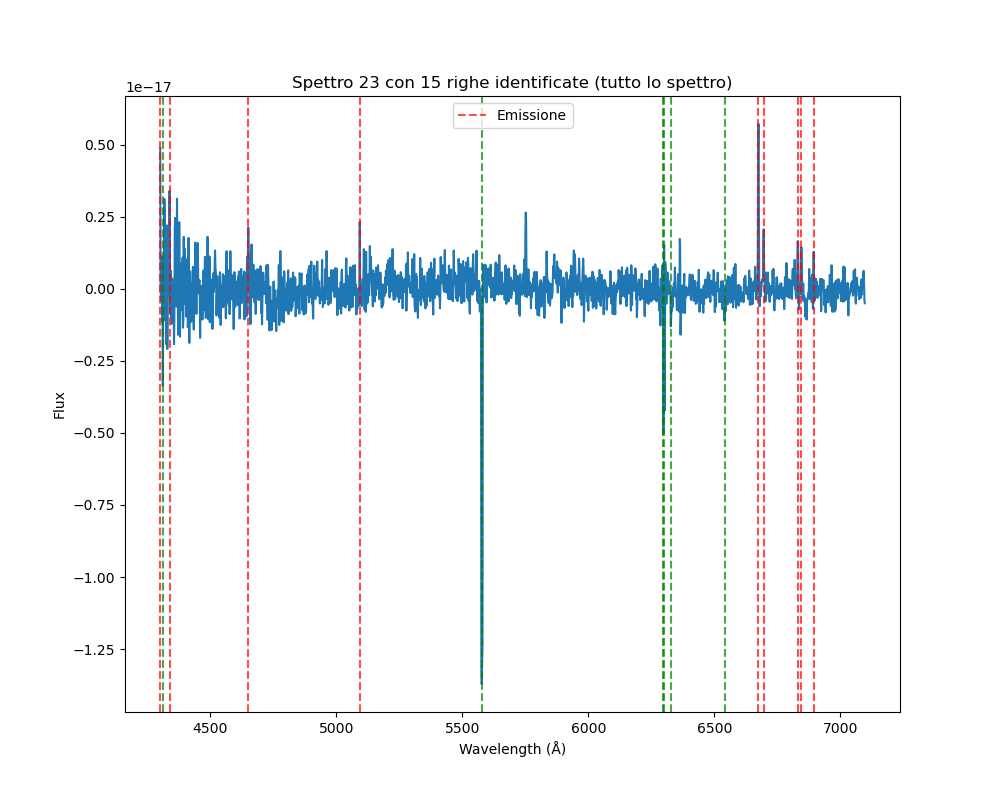

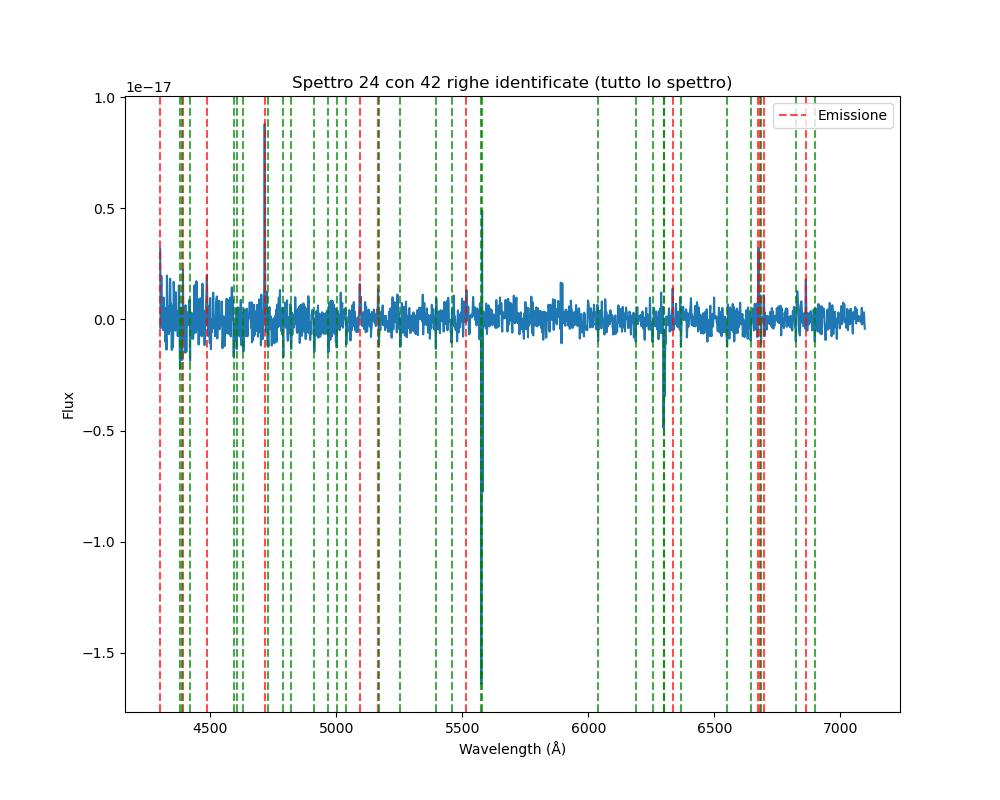

In [15]:
all_lines = []
noise_factor = [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 4, 4, 4, 5, 4, 3, 3, 2.5]
# Filtra per lunghezze d'onda > 4451 Å
wv_mask = wv > 0
wv_filtered = wv[wv_mask]

for i in range(24):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra[i][wv_mask]
    spectra_err_filtered = spectra_err[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    
    # Crea lo spettro per TUTTO il range filtrato (senza ritagliare i bordi)
    spectrum_no_continuum_full = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux=flux_continuum_subtracted,
        uncertainty=StdDevUncertainty(spectra_err_filtered * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe su TUTTO lo spettro filtrato (senza escludere i bordi)
    lines = find_lines_threshold(spectrum_no_continuum_full, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (tutto lo spettro, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            line_idx = np.argmin(np.abs(wv_filtered - line_pos.value))
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[line_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    ax3.legend()
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (tutto lo spettro)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [29]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6
l_OI = 6300.3

#lines_1 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_2 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
#lines_3 = [l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_4 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_5 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_6 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_7 = [l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_8 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_9 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_10 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_11 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_12 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_13 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_14 = [l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_15 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_16 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_17 = [l_OIII_2, l_HA, l_NII_2, l_SII_1]
lines_18 = [l_OIII_2, l_HA, l_NII_2, l_SII_1]
lines_19 = [l_HB, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_20 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_21 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_22 = [l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_23 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_24 = [l_OIII_2, l_HA, l_NII_2]

#lines_spectrum_1 = all_lines[0]['line_center'] 
#lines_spectrum_2 = all_lines[1]['line_center'] 
#lines_spectrum_3 = all_lines[2]['line_center'] 
lines_spectrum_4 = all_lines[3]['line_center'] 
lines_spectrum_5 = all_lines[4]['line_center'] 
lines_spectrum_6 = [4416.179999999966, 4946.019999999809, 5045.17999999978, 5094.019999999766, 5979.059999999505, 6661.3399999993035, 6676.139999999299, 6696.859999999293, 6833.019999999253, 6847.8199999992485 ]
lines_spectrum_7 = all_lines[6]['line_center'] 
lines_spectrum_8 = all_lines[7]['line_center'] 
lines_spectrum_9 = [4946.019999999809, 5092.539999999766, 6676.139999999299, 6696.859999999293, 6833.019999999253, 6847.8199999992485]
lines_spectrum_10 = all_lines[9]['line_center']
lines_spectrum_11 = [4946.019999999809, 5094.019999999766, 6676.139999999299, 6696.859999999293, 6833.019999999253, 6847.8199999992485]
lines_spectrum_12 = [5094.019999999766, 6676.139999999299, 6696.859999999293, 6831.539999999253, 6847.8199999992485]
lines_spectrum_13 = [4944.53999999981, 5092.539999999766, 6676.139999999299, 6696.859999999293, 6831.539999999253, 6846.339999999249]
lines_spectrum_14 = [4944.53999999981, 5043.699999999781, 5092.539999999766, 6661.3399999993035, 6676.139999999299, 6696.859999999293, 6831.539999999253,  6846.339999999249]
lines_spectrum_15 = all_lines[14]['line_center']
lines_spectrum_16 = [4944.53999999981, 5092.539999999766, 6674.6599999992995, 6695.379999999293, 6831.539999999253, 6846.339999999249]
lines_spectrum_17 = [5092.539999999766, 6674.6599999992995, 6695.379999999293, 6831.539999999253]
lines_spectrum_18 = all_lines[17]['line_center']
lines_spectrum_19 = [4944.53999999981, 6674.6599999992995, 6695.379999999293, 6831.539999999253, 6844.859999999249]
lines_spectrum_20 = all_lines[19]['line_center']
lines_spectrum_21 = [5092.539999999766, 6674.6599999992995, 6695.379999999293, 6830.059999999254, 6844.859999999249]
lines_spectrum_22 = [4944.53999999981, 5092.539999999766, 6674.6599999992995, 6695.379999999293, 6831.539999999253, 6844.859999999249]
lines_spectrum_23 = [5092.539999999766, 6674.6599999992995, 6695.379999999293, 6830.059999999254, 6844.859999999249]
lines_spectrum_24 = [5092.539999999766, 6674.6599999992995, 6695.379999999293]

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
#z_1_mean, z_1_std = redshift(lines_1, lines_spectrum_1)    
#z_2_mean, z_2_std = redshift(lines_2, lines_spectrum_2)    
#z_3_mean, z_3_std = redshift(lines_3, lines_spectrum_3)    
z_4_mean, z_4_std = redshift(lines_4, lines_spectrum_4)
z_5_mean, z_5_std = redshift(lines_5, lines_spectrum_5) 
z_6_mean, z_6_std = redshift_hand(lines_6, lines_spectrum_6) 
z_7_mean, z_7_std = redshift(lines_7, lines_spectrum_7) 
z_8_mean, z_8_std = redshift(lines_8, lines_spectrum_8) 
z_9_mean, z_9_std = redshift_hand(lines_9, lines_spectrum_9) 
z_10_mean, z_10_std = redshift(lines_10, lines_spectrum_10) 
z_11_mean, z_11_std = redshift_hand(lines_11, lines_spectrum_11) 
z_12_mean, z_12_std = redshift_hand(lines_12, lines_spectrum_12) 
z_13_mean, z_13_std = redshift_hand(lines_13, lines_spectrum_13) 
z_14_mean, z_14_std = redshift_hand(lines_14, lines_spectrum_14) 
z_15_mean, z_15_std = redshift(lines_15, lines_spectrum_15)
z_16_mean, z_16_std = redshift_hand(lines_16, lines_spectrum_16) 
z_17_mean, z_17_std = redshift_hand(lines_17, lines_spectrum_17)
z_18_mean, z_18_std = redshift(lines_18, lines_spectrum_18) 
z_19_mean, z_19_std = redshift_hand(lines_19, lines_spectrum_19)
z_20_mean, z_20_std = redshift(lines_20, lines_spectrum_20) 
z_21_mean, z_21_std = redshift_hand(lines_21, lines_spectrum_21) 
z_22_mean, z_22_std = redshift_hand(lines_22, lines_spectrum_22) 
z_23_mean, z_23_std = redshift_hand(lines_23, lines_spectrum_23) 
z_24_mean, z_24_std = redshift_hand(lines_24, lines_spectrum_24)

z = [np.nan, np.nan, np.nan, z_4_mean, z_5_mean, z_6_mean, z_7_mean, z_8_mean, z_9_mean, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, z_15_mean, z_16_mean, z_17_mean, z_18_mean, z_19_mean, z_20_mean, z_21_mean, z_22_mean, z_23_mean, z_24_mean]
z_err = [np.nan, np.nan, np.nan, z_4_std, z_5_std, z_6_std, z_7_std, z_8_std, z_9_std, z_10_std, z_11_std, z_12_std, z_13_std, z_14_std, z_15_std, z_16_std, z_17_std, z_18_std, z_19_std, z_20_std, z_21_std, z_22_std, z_23_std, z_24_std]

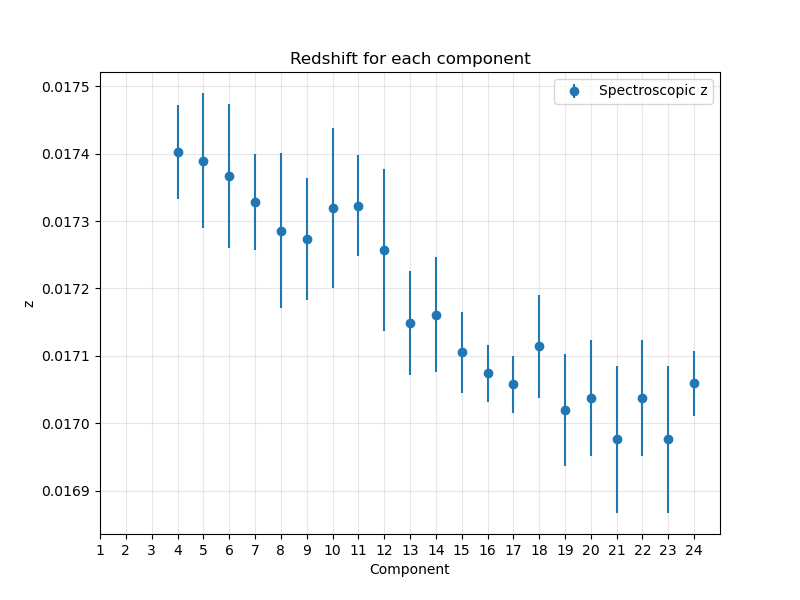

In [30]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 25, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
#plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift_grad', bbox_inches='tight')
plt.grid(alpha = 0.3)

red_table = np.column_stack((z, z_err))
np.savetxt('redshift_grad.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [34]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='24ext', num_spectra=24):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [35]:
SNR_HB = np.zeros(24)
signal_HB = np.zeros(24)
noise_HB = np.zeros(24)
SNR_SII_1 = np.zeros(24)
signal_SII_1 = np.zeros(24)
noise_SII_1 = np.zeros(24)
SNR_SII_2 = np.zeros(24)
signal_SII_2 = np.zeros(24)
noise_SII_2 = np.zeros(24)
SNR_NII_1 = np.zeros(24)
signal_NII_1 = np.zeros(24)
noise_NII_1 = np.zeros(24)
SNR_NII_2 = np.zeros(24)
signal_NII_2 = np.zeros(24)
noise_NII_2 = np.zeros(24)
SNR_HA = np.zeros(24)
signal_HA = np.zeros(24)
noise_HA = np.zeros(24)
SNR_OIII_1 = np.zeros(24)
signal_OIII_1 = np.zeros(24)
noise_OIII_1 = np.zeros(24)
SNR_OIII_2 = np.zeros(24)
signal_OIII_2 = np.zeros(24)
noise_OIII_2 = np.zeros(24)

for i in range(24):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                  SNR    Signal     Noise
Spettro_1         NaN       NaN       NaN
Spettro_2         NaN       NaN       NaN
Spettro_3         NaN       NaN       NaN
Spettro_4   20.125246  0.267630  0.013298
Spettro_5   60.029030  1.037496  0.017283
Spettro_6   56.481390  0.835172  0.014787
Spettro_7   11.086026  0.222945  0.020110
Spettro_8    8.510155  0.157523  0.018510
Spettro_9   13.454184  0.229735  0.017075
Spettro_10   7.761184  0.205564  0.026486
Spettro_11   6.228657  0.167550  0.026900
Spettro_12   2.205999  0.184615  0.083688
Spettro_13  16.346073  0.340632  0.020839
Spettro_14  25.715445  0.431881  0.016795
Spettro_15  10.681296  0.242080  0.022664
Spettro_16  10.061019  0.099426  0.009882
Spettro_17   4.434611  0.065952  0.014872
Spettro_18   1.464680  0.030755  0.020998
Spettro_19   6.627234  0.102080  0.015403
Spettro_20   6.713765  0.118713  0.017682
Spettro_21   6.134071  0.090287  0.014719
Spettro_22   2.527948  0.032547  0.012875
Spettro_23   1.078329  0.013487  0

'24ext\\SNR_OIII_2.csv'

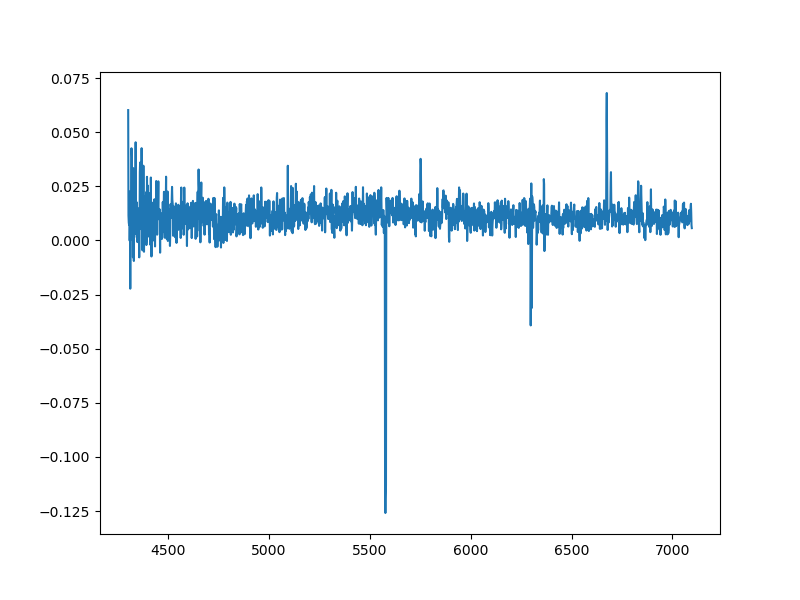

In [36]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[22])

In [29]:
l_OIII_2

5163.241907016047